<a href="https://colab.research.google.com/github/Omar-Qaid/CNNs/blob/main/CCNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training model...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 30ms/step - accuracy: 0.8879 - loss: 0.3616 - val_accuracy: 0.9808 - val_loss: 0.0563
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9856 - loss: 0.0475 - val_accuracy: 0.9897 - val_loss: 0.0333
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 28ms/step - accuracy: 0.9890 - loss: 0.0340 - val_accuracy: 0.9894 - val_loss: 0.0355
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9928 - loss: 0.0238 - val_accuracy: 0.9891 - val_loss: 0.0384
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9948 - loss: 0.0180 - val_accuracy: 0.9912 - val_loss: 0.0291


Saving 3.png to 3.png


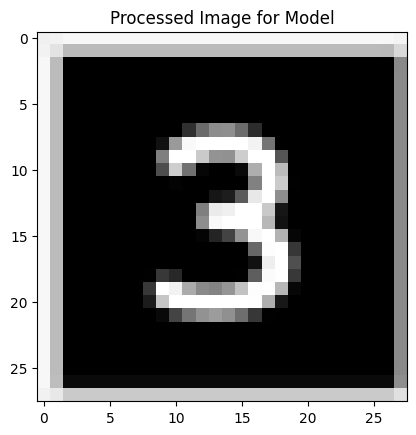

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step

Prediction: 3
Confidence: 99.86%


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import io

# --- 1. Load and preprocess the MNIST dataset ---
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255

train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

# --- 2. Define and Compile the CNN model ---
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# --- 3. Train the model ---
print("Training model...")
model.fit(train_images, train_labels, epochs=5, validation_data=(test_images, test_labels))


# Implementation Code ,we can use the PIL (Pillow) library to handle the image loading and resizing ---
# --- 4. Function to Predict Uploaded Image ---
def predict_uploaded_image(img_path):
    # Load image, convert to grayscale ('L'), and resize to 28x28
    img = Image.open(img_path).convert('L').resize((28, 28))

    # Convert to array and normalize
    img_array = np.array(img).astype('float32') / 255

    # IMPORTANT: MNIST is white digits on black background.
    # If your upload is black ink on white paper, we must invert it.
    # We check if the center pixel is brighter than the corner to guess if inversion is needed.
    if img_array[14, 14] < 0.5:
        img_array = 1 - img_array

    # Show what the model actually "sees"
    plt.imshow(img_array, cmap='gray')
    plt.title("Processed Image for Model")
    plt.show()

    # Reshape for prediction (1 sample, 28x28, 1 channel)
    img_array = img_array.reshape((1, 28, 28, 1))

    prediction = model.predict(img_array)
    digit = np.argmax(prediction)
    confidence = np.max(prediction)

    print(f"\nPrediction: {digit}")
    print(f"Confidence: {confidence * 100:.2f}%")

# --- 5. Upload Trigger (For Google Colab) ---
from google.colab import files
uploaded = files.upload()

for filename in uploaded.keys():
    predict_uploaded_image(filename)